In [ ]:
!pip install rasterio shapely tqdm

In [ ]:
import json
import os
import numpy as np
import rasterio
from rasterio.windows import Window
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
from tqdm import tqdm


In [ ]:
DATA_DIR = "/content/drive/MyDrive/BDA"   # folder where you uploaded everything

FILES = [
    "05-08-2020-MussettBayouFire-01",
    "05-08-2020-MussettBayouFire-NorthOf98",
    "05-08-2020-MussettBayouFire-SouthOf98-AnchorLakeDr",
    "05-08-2020-MussettBayouFire-SouthOf98-DelbertLn",
    "05-08-2020-MussettBayouFire-SouthOf98-LakeParkCove"
]

In [ ]:
def extract_building_patch(dataset, building, patch_size=128):
    """
    Extracts a fixed-size image patch centered on a building
    using pixel-aligned coordinates.
    """
    pixel_coords = building["pixels"]

    xs = [pt["x"] for pt in pixel_coords]
    ys = [pt["y"] for pt in pixel_coords]

    center_col = int(np.mean(xs))
    center_row = int(np.mean(ys))

    center_col = np.clip(center_col, 0, dataset.width - 1)
    center_row = np.clip(center_row, 0, dataset.height - 1)

    half = patch_size // 2

    min_row = max(0, center_row - half)
    max_row = min(dataset.height, center_row + half)
    min_col = max(0, center_col - half)
    max_col = min(dataset.width, center_col + half)

    if max_row - min_row < patch_size or max_col - min_col < patch_size:
        return None

    window = Window(
        col_off=min_col,
        row_off=min_row,
        width=patch_size,
        height=patch_size
    )

    patch = dataset.read([1, 2, 3], window=window)
    patch = np.transpose(patch, (1, 2, 0))

    if patch.max() == 0:
        return None

    return patch

In [ ]:
file_name = FILES[0]

tif_path = os.path.join(DATA_DIR, file_name + ".geo.tif")
json_path = os.path.join(DATA_DIR, file_name + ".geo.tif.json")

with open(json_path) as f:
    annotations = json.load(f)

dataset = rasterio.open(tif_path)

samples = []

for building in tqdm(annotations):
    patch = extract_building_patch(dataset, building)

    if patch is not None:
        samples.append((patch, building["label"]))

print("Total valid samples:", len(samples))


100%|██████████| 16/16 [00:14<00:00,  1.12it/s]

Total valid samples: 16


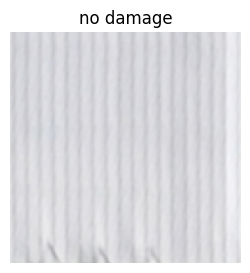

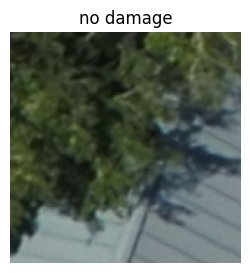

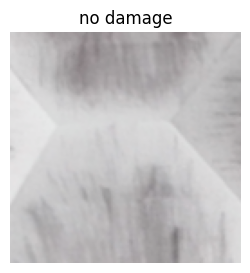

In [ ]:
for i in range(3):
    img, label = samples[i]

    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")
    plt.show()

In [ ]:
all_samples = []

for file_name in FILES:
    print(f"\nProcessing {file_name}")

    tif_path = os.path.join(DATA_DIR, file_name + ".geo.tif")
    json_path = os.path.join(DATA_DIR, file_name + ".geo.tif.json")

    with open(json_path) as f:
        annotations = json.load(f)

    dataset = rasterio.open(tif_path)

    for building in tqdm(annotations):
        patch = extract_building_patch(dataset, building)

        if patch is not None:
            all_samples.append({
                "image": patch,
                "label": building["label"],
                "source": file_name
            })

print("\nTOTAL samples collected:", len(all_samples))



Processing 05-08-2020-MussettBayouFire-01


100%|██████████| 16/16 [00:00<00:00, 64.13it/s]



Processing 05-08-2020-MussettBayouFire-NorthOf98


100%|██████████| 21/21 [00:05<00:00,  3.98it/s]



Processing 05-08-2020-MussettBayouFire-SouthOf98-AnchorLakeDr


...


Processing 05-08-2020-MussettBayouFire-SouthOf98-DelbertLn


100%|██████████| 37/37 [00:13<00:00,  2.84it/s]



Processing 05-08-2020-MussettBayouFire-SouthOf98-LakeParkCove


100%|██████████| 16/16 [00:08<00:00,  1.79it/s]


TOTAL samples collected: 127


In [ ]:
from collections import Counter

labels = [s["label"] for s in all_samples]
Counter(labels)

Counter({'no damage': 74,
         'un-classified': 6,
         'destroyed': 39,
         'minor damage': 7,
         'major damage': 1})

In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/BDA"
PREP_DIR = os.path.join(BASE_DIR, "preprocessed")

os.makedirs(PREP_DIR, exist_ok=True)

print("Preprocessed folder ready at:", PREP_DIR)

Preprocessed folder ready at: /content/drive/MyDrive/BDA/preprocessed


In [ ]:
import numpy as np

np.save(os.path.join(PREP_DIR, "images.npy"),
        np.array([s["image"] for s in all_samples]))

np.save(os.path.join(PREP_DIR, "labels.npy"),
        np.array([s["label"] for s in all_samples]))

np.save(os.path.join(PREP_DIR, "sources.npy"),
        np.array([s["source"] for s in all_samples]))

print("✅ Preprocessed dataset saved successfully")

✅ Preprocessed dataset saved successfully


In [ ]:
import numpy as np

BASE_DIR = "/content/drive/MyDrive/BDA/preprocessed"

images = np.load(f"{BASE_DIR}/images.npy")
labels = np.load(f"{BASE_DIR}/labels.npy")
sources = np.load(f"{BASE_DIR}/sources.npy")

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Sources shape:", sources.shape)

Images shape: (127, 128, 128, 3)
Labels shape: (127,)
Sources shape: (127,)


In [ ]:
unique_sources = np.unique(sources)
unique_sources

array(['05-08-2020-MussettBayouFire-01',
       '05-08-2020-MussettBayouFire-NorthOf98',
       '05-08-2020-MussettBayouFire-SouthOf98-AnchorLakeDr',
       '05-08-2020-MussettBayouFire-SouthOf98-DelbertLn',
       '05-08-2020-MussettBayouFire-SouthOf98-LakeParkCove'], dtype='<U50')

In [ ]:
TEST_SOURCES = [
   "05-08-2020-MussettBayouFire-01",
    "05-08-2020-MussettBayouFire-NorthOf98"
]

TRAIN_SOURCES = [
    "05-08-2020-MussettBayouFire-SouthOf98-DelbertLn",
    "05-08-2020-MussettBayouFire-SouthOf98-AnchorLakeDr",
    "05-08-2020-MussettBayouFire-SouthOf98-LakeParkCove"
]

In [ ]:
valid_mask = labels != "un-classified"

images = images[valid_mask]
labels = labels[valid_mask]
sources = sources[valid_mask]

print("Remaining samples after filtering:", len(labels))

Remaining samples after filtering: 121


In [ ]:
train_mask = np.isin(sources, TRAIN_SOURCES)
test_mask = np.isin(sources, TEST_SOURCES)

X_train = images[train_mask]
y_train = labels[train_mask]

X_test = images[test_mask]
y_test = labels[test_mask]

print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Train samples: 87
Test samples: 34


In [ ]:
#Check label distribution

from collections import Counter

print("Train label distribution:")
print(Counter(y_train))

print("\nTest label distribution:")
print(Counter(y_test))

Train label distribution:
Counter({np.str_('no damage'): 43, np.str_('destroyed'): 37, np.str_('minor damage'): 6, np.str_('major damage'): 1})

Test label distribution:
Counter({np.str_('no damage'): 31, np.str_('destroyed'): 2, np.str_('minor damage'): 1})


In [ ]:
# Encode labels
label_to_id = {
    "no damage": 0,
    "minor damage": 1,
    "major damage": 2,
    "destroyed": 3
}

y_train_enc = np.array([label_to_id[l] for l in y_train])
y_test_enc = np.array([label_to_id[l] for l in y_test])

print("Encoded labels example:", y_train_enc[:10])

Encoded labels example: [3 3 3 3 0 0 0 1 3 0]


In [ ]:
# Normalize images (model-ready)

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Pixel range:", X_train.min(), X_train.max())

Pixel range: 0.0 1.0


PHASE 3 — RESNET TRAINING

In [ ]:
!pip install torch torchvision

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

In [ ]:
print(X_train.shape, y_train_enc.shape)
print(X_test.shape, y_test_enc.shape)

(87, 128, 128, 3) (87,)
(34, 128, 128, 3) (34,)


In [ ]:
class BuildingDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
train_transform = transforms.Compose([
    transforms.ToTensor(),  # (H,W,C) → (C,H,W) + [0,1]
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = train_transform

In [ ]:
train_dataset = BuildingDataset(X_train, y_train_enc, transform=train_transform)
test_dataset = BuildingDataset(X_test, y_test_enc, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 3
Test batches: 2


In [ ]:
num_classes = 4  # no damage, minor, major, destroyed

model = models.resnet18(pretrained=True)

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


cpu


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate(model, loader):
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            predicted = torch.argmax(outputs, dim=1).cpu().numpy()

            preds.extend(predicted)
            targets.extend(labels.numpy())

    acc = accuracy_score(targets, preds)
    f1 = f1_score(targets, preds, average="macro")

    return acc, f1

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def train_model(model, train_loader, test_loader, optimizer, criterion, epochs=10):

    # -------- TRAINING --------
    for epoch in range(epochs):
        train_one_epoch(model, train_loader, optimizer, criterion)

    # -------- FINAL EVALUATION --------
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_targets.extend(labels.numpy())

    # -------- METRICS --------
    acc = accuracy_score(all_targets, all_preds)

    print("\nFINAL TEST RESULTS")
    print("=" * 40)
    print(f"Accuracy: {acc:.4f}\n")

    print("Classification Report:")
    print(classification_report(
        all_targets,
        all_preds,
        digits=4
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(all_targets, all_preds))


In [ ]:
#Baseline model
train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=10
)


FINAL TEST RESULTS
Accuracy: 0.9412

Classification Report:
              precision    recall  f1-score   support

           0     0.9677    0.9677    0.9677        31
           1     0.0000    0.0000    0.0000         1
           3     0.6667    1.0000    0.8000         2

    accuracy                         0.9412        34
   macro avg     0.5448    0.6559    0.5892        34
weighted avg     0.9216    0.9412    0.9294        34

Confusion Matrix:
[[30  0  1]
 [ 1  0  0]
 [ 0  0  2]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [ ]:
# Binary damage classification
# 0 → no damage
# 1 → damaged (minor + major + destroyed)

def merge_binary(label):
    if label == 0:
        return 0
    else:
        return 1

y_train_bin = np.array([merge_binary(l) for l in y_train_enc])
y_test_bin = np.array([merge_binary(l) for l in y_test_enc])

print("Train distribution:", np.unique(y_train_bin, return_counts=True))
print("Test distribution:", np.unique(y_test_bin, return_counts=True))


Train distribution: (array([0, 1]), array([43, 44]))
Test distribution: (array([0, 1]), array([31,  3]))


In [ ]:
train_dataset = BuildingDataset(X_train, y_train_bin, transform=train_transform)
test_dataset = BuildingDataset(X_test, y_test_bin, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [ ]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=10
)



FINAL TEST RESULTS
Accuracy: 0.9706

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9677    0.9836        31
           1     0.7500    1.0000    0.8571         3

    accuracy                         0.9706        34
   macro avg     0.8750    0.9839    0.9204        34
weighted avg     0.9779    0.9706    0.9724        34

Confusion Matrix:
[[30  1]
 [ 0  3]]
